# 🔴 Support Vector Machine (SVM)
---

## 📑 Table of Contents
1. [Introduction & Definition](#1.-Introduction-&-Definition)
2. [How It Works — Math & Intuition](#2.-How-It-Works-—-Math-&-Intuition)
3. [When To Use](#3.-When-To-Use)
4. [Pros & Cons](#4.-Pros-&-Cons)
5. [Dataset Upload & Exploration](#5.-Dataset-Upload-&-Exploration)
   - 5.1 Import Libraries
   - 5.2 Load Dataset
   - 5.3 Exploratory Data Analysis (EDA)
   - 5.4 Preprocessing & Feature Engineering
6. [Training the Model](#6.-Training-the-Model)
   - 6.1 Train/Validation/Test Split
   - 6.2 Fit the Model
7. [Validation](#7.-Validation)
   - 7.1 Cross-Validation
   - 7.2 Validation Metrics
8. [Testing](#8.-Testing)
   - 8.1 Final Test Set Evaluation
   - 8.2 Confusion Matrix & Classification Report
9. [Optimization / Hyperparameter Tuning](#9.-Optimization-/-Hyperparameter-Tuning)
   - 9.1 GridSearchCV / RandomizedSearchCV
   - 9.2 Best Parameters & Retrain
10. [Kernel Visualization (make_moons)](#10.-Kernel-Visualization)
11. [Tips & Tricks Summary](#11.-Tips-&-Tricks-Summary)
12. [Conclusion](#12.-Conclusion)

## 1. Introduction & Definition

**Support Vector Machine (SVM)** is one of the most powerful, theoretically elegant, and geometrically intuitive classification algorithms in all of supervised machine learning. At its core, SVM answers a deceptively simple question: given a set of labelled training points in a feature space, what is the optimal boundary — the **hyperplane** — that separates the classes with the maximum possible margin?

Unlike simpler algorithms that merely seek *any* boundary capable of separating the training data, an SVM rigorously searches for the hyperplane positioned exactly in the middle of the empty space between the two classes. The data points that lie strictly on the edges of this margin are known as **Support Vectors**. They are called "support vectors" because they literally support and define the margin's location. If you were to remove all other data points from the training set, the decision boundary would not move an inch. This characteristic makes SVM fundamentally sparse and robust against outliers that lie far away from the boundary.

### The Hard Margin Formulation
When data is perfectly linearly separable, we define two parallel hyperplanes that pass through the closest points of each class. The distance between these two hyperplanes is precisely $\frac{2}{\|w\|}$. To maximize this margin width, we must minimize $\|w\|$. The formal optimization problem is written mathematically as minimizing a quadratic function subject to linear constraints:

$$ \min_{w,b} \frac{1}{2} \|w\|^2 $$
$$ \text{Subject to: } y_i (w^T x_i + b) \ge 1 \quad \forall i $$

### The Soft Margin Formulation
However, real-world data is inherently messy. It is rarely perfectly separable due to overlapping distributions, outliers, and noise. If we strictly enforced a hard margin, the SVM might either fail to find a solution or create an extremely narrow margin heavily skewed by a single outlier. To remedy this, we introduce the **Soft Margin** via a regularization parameter $C$ and non-negative slack variables $\xi_i$. The slack variables allow individual points to violate the margin constraints slightly, while the $C$ parameter dictates the penalty for these violations.

$$ \min_{w,b,\xi} \frac{1}{2} \|w\|^2 + C \sum_{i=1}^n \xi_i $$
$$ \text{Subject to: } y_i (w^T x_i + b) \ge 1 - \xi_i, \quad \xi_i \ge 0 \quad \forall i $$

### The Dual Form
By applying the method of Lagrange multipliers, we translate the primal optimization problem into its **Dual Form**. Solving the dual form is often computationally easier and is strictly necessary to implement the Kernel Trick (which we will explore in the next section). The dual formulation transforms the problem so that it depends exclusively on the dot product of the input feature vectors:

$$ \max_{\alpha} \sum_{i=1}^n \alpha_i - \frac{1}{2} \sum_{i=1}^n \sum_{j=1}^n \alpha_i \alpha_j y_i y_j x_i^T x_j $$
$$ \text{Subject to: } \sum_{i=1}^n \alpha_i y_i = 0 \quad \text{and} \quad 0 \le \alpha_i \le C \quad \forall i $$

In this dual form, each data point has a corresponding multiplier $\alpha_i$. For the vast majority of points (those safely on the correct side of the margin), $\alpha_i$ evaluates precisely to zero. Only the support vectors possess an $\alpha_i > 0$. This profound mathematical reality highlights why SVMs are remarkably computationally efficient at inference time: evaluating a new prediction solely relies on a small subset of the original training data.

## 2. How It Works — Math & Intuition

Let's break down how SVM actually finds this optimal boundary using an intuitive analogy and a step-by-step mathematical perspective.

### 1. The Street Analogy
Imagine you are trying to build the widest possible straight street separating a neighbourhood of red houses (class -1) from a neighbourhood of blue houses (class +1). The sidewalks of the street are the margins. You want to place the street so that the distance from the centerline to the closest house of either colour is as large as possible. The houses that end up sitting exactly on the curb of the sidewalk are your **Support Vectors**. They constrain the width and angle of the street. 

### 2. The Kernel Trick
What happens if the two neighbourhoods are situated such that you cannot draw a straight street between them? For example, what if the red houses form a circle surrounded by blue houses? A linear hyperplane cannot separate them. 

Enter the **Kernel Trick**. We mathematically map our original features $x$ into a higher-dimensional space using a mapping function $\phi(x)$. In this new higher-dimensional space, the data might become linearly separable. However, calculating $\phi(x)$ directly can be infinitely complex. The kernel trick leverages the fact that the SVM dual formulation only requires the dot product $x_i^T x_j$. A kernel function computes this dot product in the higher-dimensional space directly, without ever actually performing the transformation:
$$ K(x_i, x_j) = \phi(x_i)^T \phi(x_j) $$

### 3. Common Kernel Functions
**Radial Basis Function (RBF) Kernel:**
The most popular kernel. It computes similarity based on distance. It maps data into an infinite-dimensional space.
$$ K(x, z) = \exp(-\gamma \|x - z\|^2) $$
The parameter $\gamma$ (gamma) controls the radius of influence of a single training point. A high $\gamma$ means the influence is tightly restricted (risking overfitting), while a low $\gamma$ means points influence the boundary from far away, resulting in a smoother decision surface.

**Polynomial Kernel:**
Useful for natural language processing or image processing.
$$ K(x, z) = (x^T z + c)^d $$

### 4. The $C$ vs $\gamma$ Interaction
When using an RBF kernel, tuning the model means finding the right balance between $C$ and $\gamma$. Imagine a 4-quadrant grid:
- **High C, High $\gamma$:** Very complex, tight boundaries around individual points. Highly prone to overfitting.
- **High C, Low $\gamma$:** Strives to classify everything correctly but with a smoother, linear-like boundary.
- **Low C, High $\gamma$:** Soft margin, but points have short reach. Forms "islands" of decision boundaries.
- **Low C, Low $\gamma$:** Very smooth boundary, heavily regularized. Prone to underfitting.

## 3. When To Use

- **High-Dimensional Sparse Data:** SVMs are exceptionally good when the number of features exceeds the number of samples. This makes them historically famous for text classification (e.g., TF-IDF matrices) and genomics.
- **Complex Non-Linear Boundaries:** When a linear classifier fails, applying an SVM with an RBF or Polynomial kernel allows the model to learn highly complex decision boundaries.
- **Small to Medium Datasets:** SVM optimization (specifically $O(N^2)$ to $O(N^3)$) is computationally expensive, making it best suited for datasets under 100,000 rows.
- **Binary Classification:** Originally designed for two classes, although they can be extended via One-vs-Rest (OvR) or One-vs-One (OvO) strategies.
- **Image Classification:** Before the deep learning era, SVMs (often combined with HOG features) were state-of-the-art for image recognition.

## 4. Pros & Cons

| ✅ Pros | ❌ Cons |
| :--- | :--- |
| **Memory Efficient:** Uses only a subset of training points (support vectors) in the decision phase. | **Computationally Expensive:** Training time scales cubically with the size of the dataset, making it slow for massive datasets. |
| **Effective in High Dimensions:** Outstanding performance even when dimensions exceed the number of samples. | **Sensitivity to Scaling:** Distance-based computations mean unscaled features will completely derail the model. |
| **Versatile (Kernels):** The Kernel trick allows for modeling highly non-linear, complex datasets. | **Black Box Nature:** Unlike Logistic Regression, non-linear SVMs do not yield easily interpretable coefficients or odds ratios. |
| **Robust to Outliers:** The margin is mostly influenced by points near the boundary, ignoring extreme distant outliers. | **No Native Probabilities:** SVMs output distances to the hyperplane. Getting probabilities (via Platt scaling) is slow and an approximation. |
| **Theoretical Guarantees:** Based on convex optimization, meaning it finds a global minimum (no local optima issues). | **Hyperparameter Sensitivity:** Requires extensive and careful grid search for $C$ and $\gamma$ to prevent over/underfitting. |

## 5. Dataset Upload & Exploration

We use sklearn's Breast Cancer dataset (binary) to train our SVM, and also a synthetic `make_moons` dataset to visually demonstrate the kernel trick.

In [1]:
# ============================================================
# SECTION 5.1 — IMPORT LIBRARIES
# ============================================================
# Data manipulation and mathematics
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

# Datasets
from sklearn.datasets import load_breast_cancer, make_moons

# Model Selection and Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.svm import SVC, LinearSVC

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, \
                            roc_auc_score, confusion_matrix, classification_report, roc_curve

# System
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ============================================================
# SECTION 5.2 — LOAD DATASET
# ============================================================
cancer_data = load_breast_cancer()
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df['target'] = cancer_data.target

print(f"Dataset Shape: {df.shape}\n")
df.info()

print("\n--- Feature Summary (First 5 Features) ---")
display(df.iloc[:, :5].describe().T)

display(df.head())

Dataset Shape: (569, 31)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### 💡 TIP for EDA
SVM is incredibly sensitive to feature scale. During EDA, we must check the spread and magnitude of our features. Also, for SVM, it is useful to check if classes appear approximately linearly separable. If they are, a linear kernel (`LinearSVC`) may suffice and will train significantly faster than an RBF kernel.

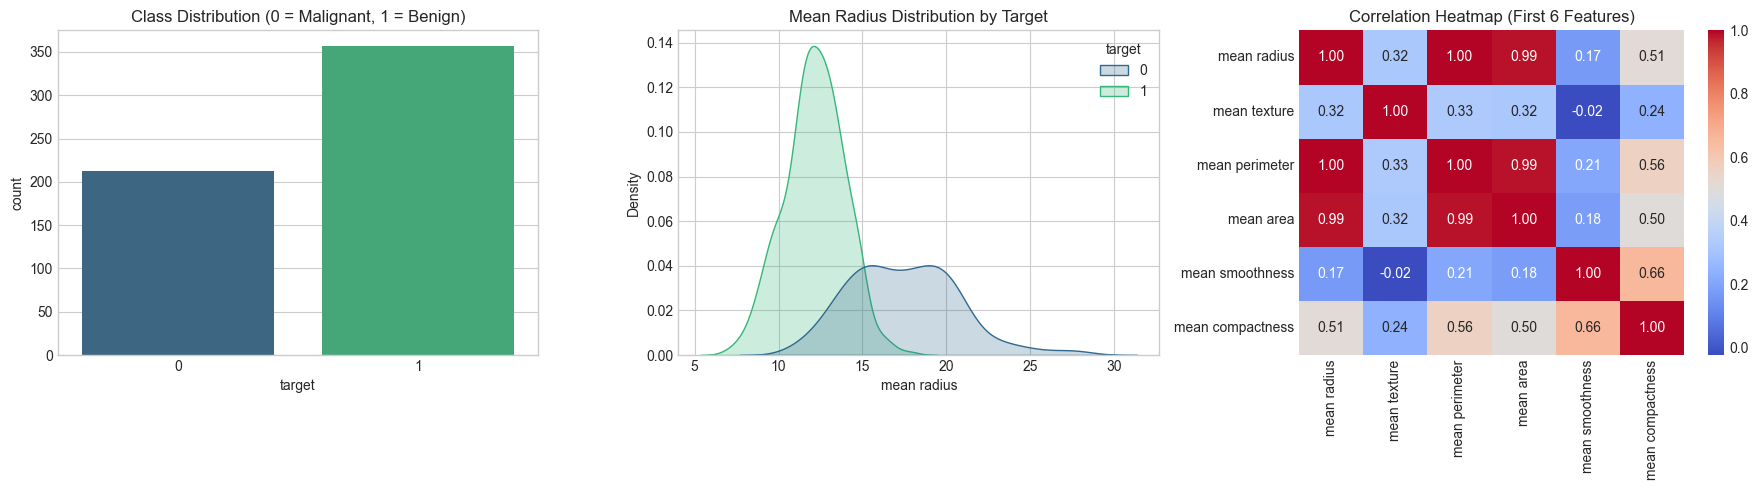

In [3]:
# ============================================================
# SECTION 5.3 — EDA
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Target Class Distribution
sns.countplot(x='target', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Class Distribution (0 = Malignant, 1 = Benign)')

# 2. KDE of Mean Radius by Target
sns.kdeplot(data=df, x='mean radius', hue='target', fill=True, ax=axes[1], palette='viridis')
axes[1].set_title('Mean Radius Distribution by Target')

# 3. Correlation Heatmap
corr_matrix = df.iloc[:, :6].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', ax=axes[2], fmt='.2f')
axes[2].set_title('Correlation Heatmap (First 6 Features)')

plt.tight_layout()
plt.show()

### 💡 SECTION 5.4 TIPS: Preprocessing & Scaling
Scaling is **CRITICAL** for SVM. Because SVM optimizes the norm of the weights $\|w\|^2$ and relies on distance calculations (like the Euclidean distance in the RBF kernel), a feature with a range of 0-10000 will utterly dominate the distance calculation compared to a feature ranging from 0-1. We will use `StandardScaler`. 

**Important:** We must fit the scaler ONLY on the training data to prevent data leakage.

In [4]:
# ============================================================
# SECTION 5.4 — PREPROCESSING
# ============================================================
# Separate features and target
X_full = df.drop('target', axis=1)
y_full = df['target']

# NOTE: We just copy here. Scaler will be fit ONLY on X_train in Section 6.1
X = X_full.copy()
y = y_full.copy()

## 6. Training the Model

In [5]:
# ============================================================
# SECTION 6.1 — TRAIN / VAL / TEST SPLIT
# ============================================================
# First, split into Train (60%) and Temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=42
)

# Next, split Temp into Validation (20%) and Test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Training Set:   {X_train.shape[0]} samples")
print(f"Validation Set: {X_val.shape[0]} samples")
print(f"Test Set:       {X_test.shape[0]} samples")

# Initialize and fit StandardScaler purely on Train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Also prepare a combined temp set for final cross-validation later
X_temp_scaled = scaler.transform(X_temp)

Training Set:   341 samples
Validation Set: 114 samples
Test Set:       114 samples


### 💡 TIP: Kernel Selection and Key SVM Parameters
- **kernel**: Use `'linear'` when you know classes are linearly separable or when dealing with incredibly high-dimensional sparse text data. Use `'rbf'` (Radial Basis Function) as the default for non-linear problems.
- **C (Regularization)**: Think of this as the inverse of the margin width tolerance. A *small C* translates to a wider margin and more leniency for misclassifications (heavily regularized). A *large C* creates a narrow margin, strictly penalizing misclassifications but severely risking overfitting.
- **gamma**: Used strictly for RBF, poly, and sigmoid kernels. It dictates the "radius of influence" of each training sample. *Low gamma* = far-reaching influence (smooth boundary). *High gamma* = short reach (tight, jagged boundary prone to overfitting).
- **probability=True**: Standard SVMs output distances to the margin, not probabilities. To get probabilities (needed for ROC AUC), `sklearn` implements an internal cross-validation (Platt scaling). This makes training significantly slower but unlocks `.predict_proba()`.

In [6]:
# ============================================================
# SECTION 6.2 — FIT THE MODEL
# ============================================================
# 1. Train a LinearSVC as a fast baseline
# WARNING: LinearSVC is much faster than SVC(kernel='linear') for large datasets
lin_svm = LinearSVC(C=1.0, max_iter=10000, random_state=42)
lin_svm.fit(X_train_scaled, y_train)

# 2. Train a full SVC with RBF kernel
rbf_svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
rbf_svm.fit(X_train_scaled, y_train)

print("--- Training Set Accuracy ---")
print(f"LinearSVC Accuracy: {lin_svm.score(X_train_scaled, y_train):.4f}")
print(f"RBF SVC Accuracy:   {rbf_svm.score(X_train_scaled, y_train):.4f}")

# TIP: Inspecting the support vectors
print("\n--- Support Vectors (RBF Model) ---")
print(f"Total Support Vectors: {rbf_svm.n_support_.sum()}")
print(f"Support Vectors per Class: {rbf_svm.n_support_}")

--- Training Set Accuracy ---
LinearSVC Accuracy: 0.9883
RBF SVC Accuracy:   0.9824

--- Support Vectors (RBF Model) ---
Total Support Vectors: 83
Support Vectors per Class: [44 39]


## 7. Validation

In [7]:
# ============================================================
# SECTION 7.1 — CROSS-VALIDATION
# ============================================================
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lin_cv_scores = cross_val_score(lin_svm, X_train_scaled, y_train, cv=cv, scoring='accuracy')
rbf_cv_scores = cross_val_score(rbf_svm, X_train_scaled, y_train, cv=cv, scoring='accuracy')

print("--- 5-Fold Cross Validation (Training Set) ---")
print(f"LinearSVC Mean CV Accuracy: {lin_cv_scores.mean():.4f} ± {lin_cv_scores.std():.4f}")
print(f"RBF SVC Mean CV Accuracy:   {rbf_cv_scores.mean():.4f} ± {rbf_cv_scores.std():.4f}")

--- 5-Fold Cross Validation (Training Set) ---
LinearSVC Mean CV Accuracy: 0.9618 ± 0.0118
RBF SVC Mean CV Accuracy:   0.9707 ± 0.0091


In [8]:
# ============================================================
# SECTION 7.2 — VALIDATION SET METRICS
# ============================================================
# Generate predictions
y_val_pred = rbf_svm.predict(X_val_scaled)
y_val_prob = rbf_svm.predict_proba(X_val_scaled)[:, 1]

print("--- Validation Set Metrics (RBF SVC) ---")
print(f"Accuracy:  {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred):.4f}")
print(f"F1 Score:  {f1_score(y_val, y_val_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_val, y_val_prob):.4f}")

--- Validation Set Metrics (RBF SVC) ---
Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1 Score:  0.9861
ROC AUC:   0.9990


### 🩺 Explaining Metrics in Context
For cancer detection, how we interpret these metrics is a matter of life and death:
- **Accuracy**: Total correct predictions. Good for an overview, but deceptive if classes are imbalanced.
- **Precision**: When the model predicts 'Benign' (class 1), how often is it actually benign? High precision limits false positives.
- **Recall**: Out of all actually Benign tumors, how many did we correctly identify? For medical diagnoses, recall is often king.
- **F1 Score**: The harmonic mean of Precision and Recall, ensuring we aren't wildly sacrificing one for the other.
- **ROC AUC**: Evaluates how well our SVM separates the two classes across all possible probability thresholds.

## 8. Testing

--- Final Test Set Classification Report ---
               precision    recall  f1-score   support

Malignant (0)       0.98      0.93      0.95        43
   Benign (1)       0.96      0.99      0.97        71

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114



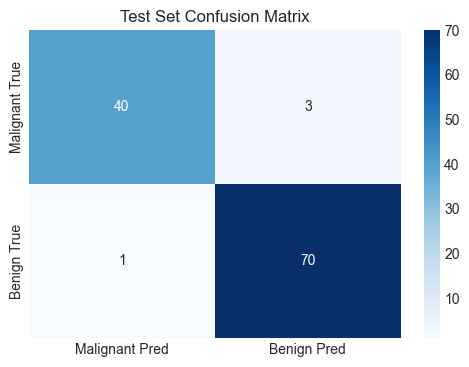

In [9]:
# ============================================================
# SECTION 8.1 & 8.2 — FINAL TEST EVAL & CONFUSION MATRIX
# ============================================================
y_test_pred = rbf_svm.predict(X_test_scaled)

print("--- Final Test Set Classification Report ---")
print(classification_report(y_test, y_test_pred, target_names=['Malignant (0)', 'Benign (1)']))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Malignant Pred', 'Benign Pred'],
            yticklabels=['Malignant True', 'Benign True'])
plt.title('Test Set Confusion Matrix')
plt.show()

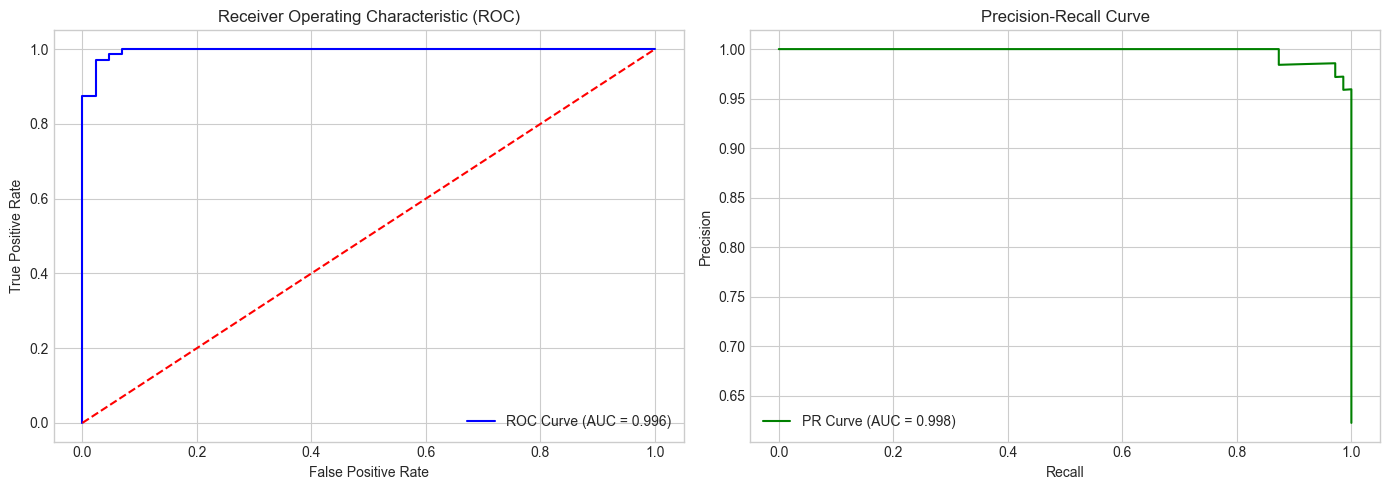

In [10]:
# ============================================================
# SECTION 8.3 — ROC CURVE
# ============================================================
from sklearn.metrics import precision_recall_curve, auc

y_test_prob = rbf_svm.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, roc_thresh = roc_curve(y_test, y_test_prob)
precision, recall, pr_thresh = precision_recall_curve(y_test, y_test_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_test_prob):.3f})')
axes[0].plot([0, 1], [0, 1], color='red', linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Receiver Operating Characteristic (ROC)')
axes[0].legend()

# Precision-Recall Curve
pr_auc = auc(recall, precision)
axes[1].plot(recall, precision, color='green', label=f'PR Curve (AUC = {pr_auc:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Optimization & Hyperparameter Tuning

### 💡 TIP: Tuning Parameters for SVM
The performance of an RBF SVM is highly dependent on discovering the optimal combination of $C$ and $\gamma$. We employ a grid search strategy over a 2D logarithmic space to locate the optimal region.

**WARNING:** SVM GridSearch can be punishingly slow. SVM training time scales between $O(n^2)$ and $O(n^3)$. If your dataset exceeds 10,000 samples, favor `RandomizedSearchCV` instead of `GridSearchCV` to sample random points in the hyperparameter space.

In [11]:
# ============================================================
# SECTION 9.1 — GRIDSEARCHCV
# ============================================================
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'kernel': ['rbf', 'poly']
}

grid_search = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,  # Use all available CPU cores
    verbose=1
)

# Fit using our temporary combined set (Train + Val) for robust tuning
grid_search.fit(X_temp_scaled, y_temp)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,estimator,SVC(probabili...ndom_state=42)
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto', ...], 'kernel': ['rbf', 'poly']}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [12]:
# ============================================================
# SECTION 9.2 — BEST PARAMETERS & RETRAIN
# ============================================================
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best ROC AUC Score:    {grid_search.best_score_:.4f}\n")

best_svm = grid_search.best_estimator_
y_opt_pred = best_svm.predict(X_test_scaled)

print("--- Optimized Final Test Evaluation ---")
print(f"Optimized Accuracy: {accuracy_score(y_test, y_opt_pred):.4f}\n")
print(classification_report(y_test, y_opt_pred, target_names=['Malignant (0)', 'Benign (1)']))

Best Parameters Found: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best ROC AUC Score:    0.9971

--- Optimized Final Test Evaluation ---
Optimized Accuracy: 0.9912

               precision    recall  f1-score   support

Malignant (0)       1.00      0.98      0.99        43
   Benign (1)       0.99      1.00      0.99        71

     accuracy                           0.99       114
    macro avg       0.99      0.99      0.99       114
 weighted avg       0.99      0.99      0.99       114



## 10. Kernel Visualization (make_moons)

To truly appreciate the power of the kernel trick visually, we shift away from the 30-dimensional Breast Cancer dataset. Let's use a simple 2D synthetic dataset (`make_moons`) where the two classes represent inter-locking crescent moons. They are categorically impossible to separate using a simple straight line.

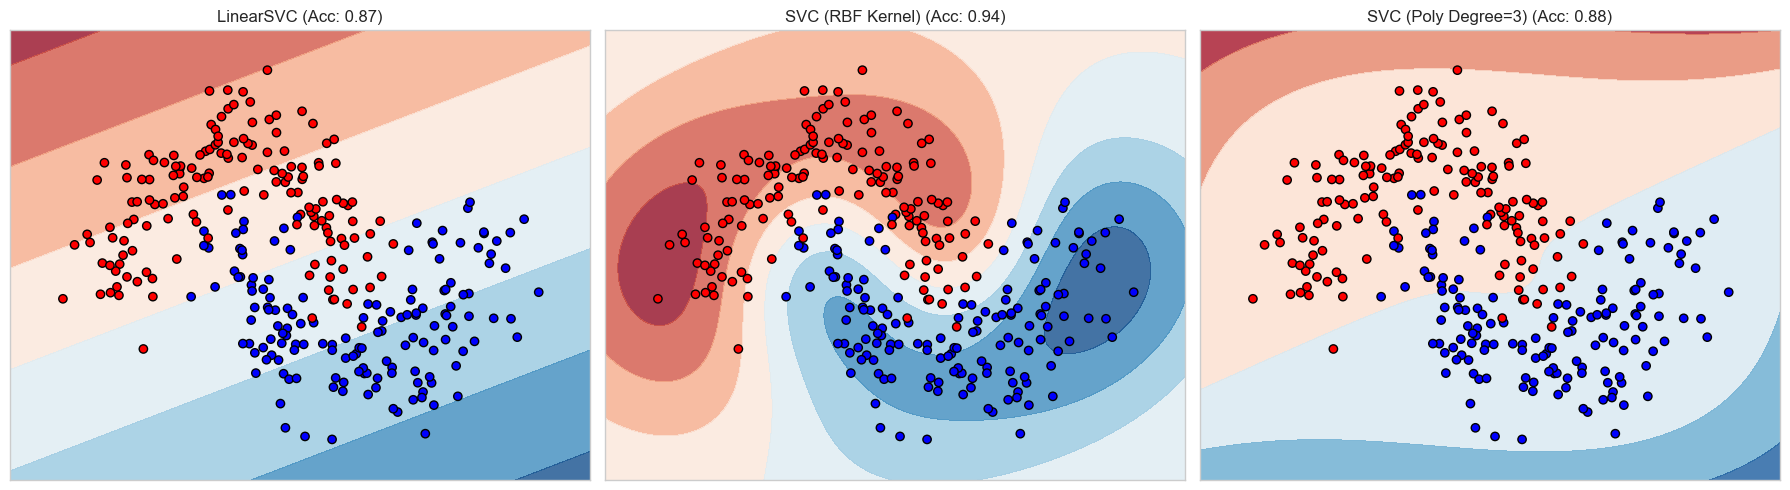

In [13]:
# ============================================================
# SECTION 10 — KERNEL VISUALIZATION
# ============================================================
from matplotlib.colors import ListedColormap

# 1. Generate Moon Dataset
X_moons, y_moons = make_moons(n_samples=300, noise=0.2, random_state=42)
scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)

# 2. Initialize Three distinct Models
models = {
    'LinearSVC': LinearSVC(C=1.0, max_iter=10000, random_state=42),
    'SVC (RBF Kernel)': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    'SVC (Poly Degree=3)': SVC(kernel='poly', degree=3, C=1.0, random_state=42)
}

# 3. Plotting Setup
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cm = plt.cm.RdBu
cm_bright = ListedColormap(['#FF0000', '#0000FF'])

xx, yy = np.meshgrid(np.arange(X_moons_scaled[:, 0].min() - 0.5, X_moons_scaled[:, 0].max() + 0.5, 0.02),
                     np.arange(X_moons_scaled[:, 1].min() - 0.5, X_moons_scaled[:, 1].max() + 0.5, 0.02))

# 4. Train and Draw Decision Boundaries
for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_moons_scaled, y_moons)
    acc = model.score(X_moons_scaled, y_moons)
    
    # Get Decision Boundary
    if hasattr(model, "decision_function"):
        Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    else:
        Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
        
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cm, alpha=0.8)
    
    # Plot training points
    ax.scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1], c=y_moons, cmap=cm_bright, edgecolors='k')
    ax.set_title(f"{name} (Acc: {acc:.2f})")
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xticks(())  # Remove axis ticks for cleaner look
    ax.set_yticks(())

plt.tight_layout()
plt.show()

## 11. Tips & Tricks Summary

1. **Scale Your Data**: The number one reason SVMs fail in production is a lack of feature scaling. Always use `StandardScaler` or `MinMaxScaler` prior to training.
2. **Linear Baseline**: Always try a `LinearSVC` before jumping to complex RBF kernels. If the data is linearly separable, RBF is just wasting CPU cycles.
3. **Use the Right Linear Implementation**: If using a linear kernel, use `LinearSVC()` instead of `SVC(kernel='linear')`. The former is built on liblinear and is immensely faster for large datasets.
4. **Parameter C Controls the Hardness**: Decreasing $C$ softens the margin, allowing more support vectors and generally generalizing better. Increasing $C$ forces a hard, strict margin.
5. **Parameter Gamma Controls the Reach**: In RBF, decreasing $\gamma$ extends the influence of individual points, creating smoother, linear-looking boundaries. Increasing $\gamma$ tightens boundaries heavily around single points.
6. **Handle Imbalanced Data**: If your target class is highly skewed (e.g., 99% vs 1%), use `class_weight='balanced'` inside the SVC parameters to automatically adjust weights inversely proportional to class frequencies.
7. **Beware the Probability Slowdown**: Setting `probability=True` initiates an expensive 5-fold cross-validation internally (Platt Scaling). If you only need hard classifications (`.predict()`), leave it as False.
8. **Grid Search is Mandatory**: An SVM with default parameters is almost never optimal. You must tune $C$ and $\gamma$ simultaneously because they interact deeply.
9. **Avoid Massive Datasets**: If $N > 100,000$, standard SVMs will crawl to a halt. Look into `SGDClassifier` or kernel approximations like `Nystroem` or Random Fourier Features.
10. **Sparsity is Your Friend**: For text data consisting of sparse matrices (like TF-IDF), SVMs (specifically linear) are mathematically guaranteed to perform exceptionally well.

## 12. Conclusion

Support Vector Machines represent a masterpiece of optimization mathematics. By shifting the objective from merely finding *a* boundary to finding the *optimal* boundary, SVM guarantees maximum margin generalization. The integration of the kernel trick further elevates the algorithm from a strict linear classifier into a highly flexible tool capable of drawing virtually any shape of decision boundary required to dissect complex data.

While they demand careful preprocessing—specifically rigorous scaling and extensive hyperparameter tuning—and are computationally heavy for massive datasets, their theoretical soundness and robustness to outliers keep them highly relevant. Mastering the interplay between the regularization parameter $C$ and kernel specifics like $\gamma$ unlocks the full architectural power of the SVM.